<a href="https://colab.research.google.com/github/iamtrask/abcGPT/blob/main/notebooks/train_gated_tent_karpathy_sts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

# abcGPT

What if you could control *which pre-training data* a GPT was leaning on, at inference time? abcGPT is an experimental fork of [Karpathy's nanoGPT](https://github.com/karpathy/nanoGPT) that adds a slider to the generator. You drag it from 0 to 1 and the model smoothly morphs from one training corpus to another, using a single set of weights.

## what's going on

Every major AI product smushes together all of the pre-training data sources into an irreversible tangle of neurons. When you prompt a model, you can kindof get different voices/styles out of the model, but you don't really have a rigorous way to control that. For example, if we train nanoGPT on [tinyshakespeare](https://github.com/karpathy/char-rnn/blob/master/data/tinyshakespeare/input.txt) + [TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories), it ends up sounding like a blend of both, and while we can feel our way around by prompting things like "cicero:" or "the boy walked the dog" to try to coax the model into sounding like one or the other, there's no real way to keep it there.

abcGPT tries to add a formal knob which allows you to control the voice of your GPT, and the way it works is by assigning each neuron to a corpus *before training even starts*, so that each neuron grows up specialized to one of the two. Specifically, for every gated unit in the network (residual stream channels, MLP inner units, attention heads), we sample a number `m ~ Beta(0.5, 0.5)` once at init and then freeze it. Beta(0.5, 0.5) is U-shaped on purpose, so most units land very near 0 or very near 1, with a thinner population in the middle (you'll see the histogram in the "Mask summary" cell below).

So we end up with roughly 20% of units sitting near 0 (these will be TinyStories specialists), another 20% sitting near 1 (Shakespeare specialists), and the rest scattered in the middle (call them halfsies). Each unit's `m` is its permanent specialty label, and it doesn't change during training. Now at inference time, the user passes in an alpha in [0, 1] and we gate every unit's activation by a smooth tent peaked at α = m:

```
gate(α, m) = cos²(π/2 · |α - m| / max(m, 1-m))
```

So at α=1, the m≈1 units fire full strength and the m≈0 units are completely off. At α=0, the opposite. The halfsies peak somewhere in the middle and hand off smoothly as you slide α around. During training, every iter we just sample a random α and then draw a batch corpus from Bernoulli(α), so high α gives us mostly Shakespeare batches. Crucially the backward pass propagates through the *hard* corpus-aligned mask rather than the soft tent, so a Shakespeare batch only ever updates Shakespeare-aligned and halfsies units, never TinyStories specialists. The soft tent only comes out at inference, where it's what makes the slider feel continuous as you drag it.

And it works. After 10k iters on a T4, per-corpus held-out val loss tracks the slider quite nicely (see the "Slider sweep" cell below). One set of weights, around 10.7M params, trained on tinyshakespeare plus a 1.5MB slice of TinyStories. The slider really does just route which neurons get to talk.

The whole notebook trains in ~90 minutes on a free Colab T4. The final cell drops an ipywidgets slider in front of the trained model so you can drag it around in-browser and watch the output morph live.

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, sys
if not os.path.exists('/content/abcGPT'):
    !git clone --depth 1 https://github.com/iamtrask/abcGPT.git /content/abcGPT
else:
    !cd /content/abcGPT && git pull --rebase --autostash
%cd /content/abcGPT
if '/content/abcGPT' not in sys.path:
    sys.path.insert(0, '/content/abcGPT')

Cloning into '/content/abcGPT'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 75 (delta 21), reused 54 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 523.62 KiB | 14.54 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/abcGPT


In [3]:
!python data/shakespeare_tinystories_char/prepare.py

shakespeare chars : 1,175,652
tinystories chars : 1,498,290
combined chars    : 2,673,949
all the unique characters: 
 !"$&',-.012358:;<=>?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz|
vocab size: 75
train has 2,406,554 tokens
val has 267,395 tokens


## Data: per-corpus batch loaders

In [4]:
import os, pickle
import numpy as np
import torch

data_dir = '/content/abcGPT/data/shakespeare_tinystories_char'
train_arr = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)
vocab_size = meta['vocab_size']
stoi, itos = meta['stoi'], meta['itos']

# Find the separator '\n\n===\n\n' to split train.bin into shake / ts ranges
sep_str = '\n\n===\n\n'
sep_ids = np.array([stoi[c] for c in sep_str], dtype=np.uint16)
candidates = np.where(train_arr[:len(train_arr) - len(sep_ids) + 1] == sep_ids[0])[0]
sep_idx = None
for c in candidates:
    if np.array_equal(train_arr[c:c+len(sep_ids)], sep_ids):
        sep_idx = int(c); break
shake_end = sep_idx
ts_start = sep_idx + len(sep_ids)
ts_end = len(train_arr)
print(f'vocab_size={vocab_size}  shake=[0:{shake_end}] ts=[{ts_start}:{ts_end}]')

vocab_size=75  shake=[0:1175652] ts=[1175659:2406554]


In [5]:
block_size = 256
batch_size = 64
device = 'cuda'

def make_get_batch(arr, start, end):
    span = end - start
    def get_batch():
        ix = torch.randint(span - block_size, (batch_size,)) + start
        x = torch.stack([torch.from_numpy(arr[i:i+block_size].astype(np.int64)) for i in ix.tolist()])
        y = torch.stack([torch.from_numpy(arr[i+1:i+1+block_size].astype(np.int64)) for i in ix.tolist()])
        return x.to(device, non_blocking=True), y.to(device, non_blocking=True)
    return get_batch

shake_get_batch = make_get_batch(train_arr, 0, shake_end)
ts_get_batch    = make_get_batch(train_arr, ts_start, ts_end)

def val_range(start, end, frac=0.1):
    span = end - start
    return end - int(span * frac), end
shake_vs, shake_ve = val_range(0, shake_end)
ts_vs,    ts_ve    = val_range(ts_start, ts_end)
shake_val_batch = make_get_batch(train_arr, shake_vs, shake_ve)
ts_val_batch    = make_get_batch(train_arr, ts_vs,    ts_ve)

## Build GatedGPT (Karpathy-sized)

Same architecture as Karpathy's char-shake (n_layer=6, n_head=6, n_embd=384, ~10.65M params). The masks are sampled at init with `mask_seed=1337` so re-runs of this notebook produce the same specialty assignment.

In [7]:
from gated_gpt_tent import GatedGPT, GatedGPTConfig, train_gated

config = GatedGPTConfig(
    vocab_size=vocab_size,
    n_layer=6, n_head=6, n_embd=384,
    block_size=block_size,
    dropout=0.2,
    bias=False,
    mask_seed=1337,
)
torch.manual_seed(1337)
model = GatedGPT(config).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'GatedGPT (tent) initialized: {n_params/1e6:.2f}M params (Karpathy reference is 10.65M)')

GatedGPT (tent) initialized: 10.75M params (Karpathy reference is 10.65M)


## Mask summary

Sanity check: under Beta(0.5, 0.5) we expect ~20% of units below 0.1 (ts specialists), ~20% above 0.9 (shake specialists), and ~60% in the middle (halfsies).

M_embd (global residual-stream): mean=0.524  shake-spec=81/384  ts-spec=77/384  halfsies=226/384
layer_0_attn_heads: mean=0.535  shake-spec=2/6  ts-spec=2/6  halfsies=2/6
layer_0_mlp_inner: mean=0.523  shake-spec=337/1536  ts-spec=293/1536  halfsies=906/1536
layer_1_attn_heads: mean=0.612  shake-spec=3/6  ts-spec=1/6  halfsies=2/6
layer_1_mlp_inner: mean=0.509  shake-spec=331/1536  ts-spec=304/1536  halfsies=901/1536
layer_2_attn_heads: mean=0.483  shake-spec=0/6  ts-spec=1/6  halfsies=5/6
layer_2_mlp_inner: mean=0.499  shake-spec=291/1536  ts-spec=323/1536  halfsies=922/1536
layer_3_attn_heads: mean=0.433  shake-spec=1/6  ts-spec=3/6  halfsies=2/6
layer_3_mlp_inner: mean=0.503  shake-spec=323/1536  ts-spec=306/1536  halfsies=907/1536
layer_4_attn_heads: mean=0.438  shake-spec=2/6  ts-spec=2/6  halfsies=2/6
layer_4_mlp_inner: mean=0.483  shake-spec=280/1536  ts-spec=322/1536  halfsies=934/1536
layer_5_attn_heads: mean=0.476  shake-spec=0/6  ts-spec=1/6  halfsies=5/6
layer_5_mlp_inner: 

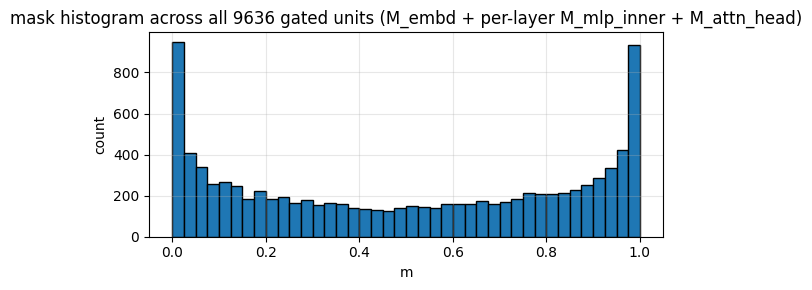

In [8]:
for k, v in model.mask_summary().items():
    print(f'{k}: mean={v["mean"]:.3f}  shake-spec={v["shake_specialist (m>0.9)"]}/{v["total"]}  '
          f'ts-spec={v["ts_specialist (m<0.1)"]}/{v["total"]}  halfsies={v["halfsies (0.1..0.9)"]}/{v["total"]}')

import matplotlib.pyplot as plt
all_m = torch.cat(
    [model.M_embd] +
    [b.mlp.M_inner for b in model.transformer.h] +
    [b.attn.M_head for b in model.transformer.h]
).cpu().numpy()
plt.figure(figsize=(6, 3))
plt.hist(all_m, bins=40, edgecolor='black')
plt.title(f'mask histogram across all {len(all_m)} gated units (M_embd + per-layer M_mlp_inner + M_attn_head)')
plt.xlabel('m'); plt.ylabel('count'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Train

Per iter: sample alpha from Beta(0.5,0.5), then choose corpus by Bernoulli(alpha) (high alpha favors shake). At alpha=1 the iter trains shake specialists on shake data; at alpha=0 it trains ts specialists on ts data; mid-alpha lands halfsies stochastically on whichever corpus came up. The val printouts at corners show the effective per-corpus loss the user will see when they drag the slider to that end.

In [ ]:
train_gated(
    model, shake_get_batch, ts_get_batch,
    n_iters=10000, lr=1e-3, warmup=100, lr_decay_iters=10000, min_lr=1e-4,
    beta2=0.99, weight_decay=0.1, grad_clip=1.0,
    alpha_dist='beta_half',
    log_interval=250, eval_interval=500, eval_iters=200,
    get_shake_val=shake_val_batch, get_ts_val=ts_val_batch,
    device=device, amp_dtype=torch.bfloat16,
)

iter   250 | alpha 0.11 |    ts | loss 2.3572 | lr 0.000999 | dt 141.5s
iter   500 | alpha 0.73 | shake | loss 2.3770 | lr 0.000996 | dt 143.8s
  >>> step 500: shake@a=1.0=2.324  ts@a=0.0=2.283  shake@a=0.5=2.400  ts@a=0.5=2.466  corpus split so far: 267 shake / 233 ts
iter   750 | alpha 0.63 | shake | loss 2.3164 | lr 0.000990 | dt 305.6s
iter  1000 | alpha 0.67 | shake | loss 2.0907 | lr 0.000982 | dt 143.7s
  >>> step 1000: shake@a=1.0=2.054  ts@a=0.0=1.887  shake@a=0.5=2.065  ts@a=0.5=1.919  corpus split so far: 511 shake / 489 ts
iter  1250 | alpha 0.23 |    ts | loss 1.8177 | lr 0.000970 | dt 306.4s
iter  1500 | alpha 0.89 | shake | loss 1.9031 | lr 0.000956 | dt 143.8s
  >>> step 1500: shake@a=1.0=1.810  ts@a=0.0=1.506  shake@a=0.5=1.833  ts@a=0.5=1.499  corpus split so far: 739 shake / 761 ts
iter  1750 | alpha 0.12 |    ts | loss 1.5448 | lr 0.000940 | dt 306.0s
iter  2000 | alpha 0.95 |    ts | loss 1.8431 | lr 0.000921 | dt 144.0s
  >>> step 2000: shake@a=1.0=1.664  ts@a=0.0

GatedGPT(
  (transformer): ModuleDict(
    (wte): Embedding(75, 384)
    (wpe): Embedding(256, 384)
    (drop): Dropout(p=0.2, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GatedBlock(
        (ln_1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (attn): GatedSelfAttention(
          (c_attn): Linear(in_features=384, out_features=1152, bias=False)
          (c_proj): Linear(in_features=384, out_features=384, bias=False)
          (resid_dropout): Dropout(p=0.2, inplace=False)
        )
        (ln_2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (mlp): GatedMLP(
          (c_fc): Linear(in_features=384, out_features=1536, bias=False)
          (c_proj): Linear(in_features=1536, out_features=384, bias=False)
          (dropout): Dropout(p=0.2, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=384, out_features=75, bias=False)
)

In [ ]:
ckpt_dir = '/content/drive/MyDrive/abcGPT/gated_tent_karpathy_sts'
os.makedirs(ckpt_dir, exist_ok=True)
torch.save({'model_state': model.state_dict(), 'config': config.__dict__}, f'{ckpt_dir}/model.pt')
print(f'saved to {ckpt_dir}/model.pt')

saved to /content/drive/MyDrive/abcGPT/gated_tent_karpathy_sts/model.pt


## Slider sweep: val loss across alpha

The model is one set of weights. We just vary alpha at forward time and re-evaluate. If the gating worked, alpha=1 should hit a shake-specialist's local minimum on shake and alpha=0 should hit a ts-specialist's on ts.

In [14]:
@torch.no_grad()
def eval_loss(alpha, get_batch_fn, n_iters=50):
    model.eval()
    losses = []
    for _ in range(n_iters):
        X, Y = get_batch_fn()
        with torch.amp.autocast(device_type=device, dtype=torch.bfloat16):
            _, loss = model(X, alpha, Y)
        losses.append(loss.item())
    return float(np.mean(losses))

alphas = np.linspace(0.0, 1.0, 11)
rows = []
for a in alphas:
    sh = eval_loss(float(a), shake_val_batch)
    ts = eval_loss(float(a), ts_val_batch)
    rows.append((a, sh, ts))
    print(f'alpha={a:.2f}  shake_val={sh:.3f}  ts_val={ts:.3f}')
rows = np.array(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rows[:,0], rows[:,1], 'o-')
axes[0].set_xlabel('alpha (1.0 = shake mode)'); axes[0].set_ylabel('val loss on tinyshakespeare')
axes[0].set_title('shake val'); axes[0].grid(alpha=0.3)
axes[1].plot(rows[:,0], rows[:,2], 'o-')
axes[1].set_xlabel('alpha (1.0 = shake mode)'); axes[1].set_ylabel('val loss on TinyStories')
axes[1].set_title('tinystories val'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

alpha=0.00  shake_val=1.586  ts_val=0.855
alpha=0.10  shake_val=1.440  ts_val=0.832
alpha=0.20  shake_val=1.316  ts_val=0.820


KeyboardInterrupt: 

## Sample text across alpha

In [13]:
def encode(s):
    return [stoi[c] for c in s if c in stoi]
def decode(ids):
    return ''.join(itos[i] for i in ids)

prompt = 'the king of '
prompt_ids = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

for a in [0.0, 0.25, 0.5, 0.75, 1.0]:
    torch.manual_seed(0)
    out = model.generate(prompt_ids, alpha=float(a), max_new_tokens=200, temperature=0.8, top_k=40)
    print('=' * 70)
    print(f'alpha = {a}')
    print(decode(out[0].tolist()))

alpha = 0.0
the king of the park of the children and put it up to the boy. He wanted to keep his cup and truck with his teddy for different friends.
Suddenly, a little girl was happy to see her head. She thought it was too s
alpha = 0.25
the king of the park .

capulet :
o , such devil ?

lucentio :
entranio ! we are here , when thou thou sets ? come , ado ,
and me , it was time to all the strick .

isabella :
why , i am to look , conside , - -
a
alpha = 0.5
the king of the prisonments ,
the other time place to each other from his soul .

king henry vi :
thou seest thou art dead .

rivers :
why wilt thou have to rich thy father ' s best ?
and now thou conside thee ? 
alpha = 0.75
the king of the prisoner ' s dead !
what is the sun there ? what was it ? where ?

richard :
thou thou seal ? come , come ; your son to the enemy
was well sad ?

buckingham :
welcome , come , give me not .

king 
alpha = 1.0
the king of york .

exeter :
why , sweet pass ' d , lord ?

duchess of york :
i shall 

In [15]:
  import ipywidgets as widgets
  from IPython.display import display, clear_output
  import torch

  prompt_w = widgets.Text(value='the king of ', description='prompt:',
                          layout=widgets.Layout(width='700px'))
  alpha_w  = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.01,
                                 description='alpha:', readout_format='.2f',
                                 continuous_update=False,
                                 layout=widgets.Layout(width='700px'))
  temp_w   = widgets.FloatSlider(value=0.8, min=0.1, max=2.0, step=0.05,
                                 description='temp:', readout_format='.2f',
                                 continuous_update=False,
                                 layout=widgets.Layout(width='700px'))
  topk_w   = widgets.IntSlider(value=40, min=1, max=75, step=1,
                               description='top_k:', continuous_update=False,
                               layout=widgets.Layout(width='700px'))
  length_w = widgets.IntSlider(value=250, min=50, max=1000, step=50,
                               description='length:', continuous_update=False,
                               layout=widgets.Layout(width='700px'))
  seed_w   = widgets.IntSlider(value=0, min=0, max=10000, step=1,
                               description='seed:', continuous_update=False,
                               layout=widgets.Layout(width='700px'))
  out_w    = widgets.Output(layout=widgets.Layout(
      border='1px solid #ccc', padding='10px',
      min_height='280px', width='820px',
      font_family='monospace', white_space='pre-wrap'))

  label_w  = widgets.HTML(
      '<b>alpha:</b> 0.0 = pure TinyStories &nbsp;·&nbsp; '
      '1.0 = pure Shakespeare &nbsp;·&nbsp; '
      '0.5 = halfsies (regenerates on slider release)')

  @torch.no_grad()
  def generate_and_show(change=None):
      encoded = encode(prompt_w.value) or [0]   # fall back to a single char if prompt is empty/all-OOV
      torch.manual_seed(seed_w.value)
      prompt_ids = torch.tensor([encoded], dtype=torch.long, device='cuda')
      out = model.generate(prompt_ids,
                           alpha=alpha_w.value,
                           max_new_tokens=length_w.value,
                           temperature=temp_w.value,
                           top_k=topk_w.value)
      text = decode(out[0].tolist())
      with out_w:
          clear_output(wait=True)
          print(text)

  for w in (prompt_w, alpha_w, temp_w, topk_w, length_w, seed_w):
      w.observe(generate_and_show, names='value')

  display(label_w, prompt_w, alpha_w, temp_w, topk_w, length_w, seed_w, out_w)
  generate_and_show()  # initial render

HTML(value='<b>alpha:</b> 0.0 = pure TinyStories &nbsp;·&nbsp; 1.0 = pure Shakespeare &nbsp;·&nbsp; 0.5 = half…

Text(value='the king of ', description='prompt:', layout=Layout(width='700px'))

FloatSlider(value=0.5, continuous_update=False, description='alpha:', layout=Layout(width='700px'), max=1.0, s…

FloatSlider(value=0.8, continuous_update=False, description='temp:', layout=Layout(width='700px'), max=2.0, mi…

IntSlider(value=40, continuous_update=False, description='top_k:', layout=Layout(width='700px'), max=75, min=1…

IntSlider(value=250, continuous_update=False, description='length:', layout=Layout(width='700px'), max=1000, m…

IntSlider(value=0, continuous_update=False, description='seed:', layout=Layout(width='700px'), max=10000)

Output(layout=Layout(border='1px solid #ccc', min_height='280px', padding='10px', width='820px'))

In [ ]:
# Paste this cell into your Colab notebook (train_gated_tent_karpathy_sts.ipynb)
# after training has completed and `model.pt` is saved to Drive.
#
# Produces /content/slider_generations_transformer_tinystories.json and
# triggers a browser download. Drop the file into
# /Users/atrask/Desktop/KB/raw/github/abc/data/ and the chapter widget
# picks it up automatically.
#
# Convention: mix=0 -> pure shakespeare, mix=1 -> pure tinystories.
# Gated model alpha: alpha=1 -> shake-spec fires, alpha=0 -> ts-spec.
# So model_alpha = 1.0 - mix.

import os, json, pickle, time
import torch
import sys

# Make sure abcGPT is in path so gated_gpt_tent is importable.
if '/content/abcGPT' not in sys.path:
    sys.path.insert(0, '/content/abcGPT')

In [ ]:
sys.path.insert(0, '/content/abcGPT')

In [ ]:
# Force reload from scratch
if 'gated_gpt_tent' in sys.modules:
    del sys.modules['gated_gpt_tent']
import gated_gpt_tent
from gated_gpt_tent import GatedGPT, GatedGPTConfig

ModuleNotFoundError: No module named 'gated_gpt_tent'

In [12]:
# Paste this entire cell into your Colab notebook (train_gated_tent_karpathy_sts.ipynb)
# after training has completed and `model.pt` is saved to Drive.
#
# Produces /content/slider_generations_transformer_tinystories.json and
# triggers a browser download. Drop the file into
# /Users/atrask/Desktop/KB/raw/github/abc/data/ and the chapter widget
# picks it up automatically.
#
# Convention: mix=0 -> pure shakespeare, mix=1 -> pure tinystories.
# Gated model alpha: alpha=1 -> shake-spec fires, alpha=0 -> ts-spec.
# So model_alpha = 1.0 - mix.
#
# This version loads gated_gpt_tent.py via exec() instead of import, because
# Colab's module-search path keeps losing the abcGPT directory between cells.

import os, json, pickle, time
import torch

# Load GatedGPT and GatedGPTConfig directly into this cell's namespace via exec
# (bypasses Python's import system entirely, which has been flaky in this notebook).
GATED_GPT_TENT_PATH = '/content/abcGPT/gated_gpt_tent.py'
assert os.path.exists(GATED_GPT_TENT_PATH), f'missing: {GATED_GPT_TENT_PATH}'
exec(open(GATED_GPT_TENT_PATH).read())
print('GatedGPT loaded via exec.')

# Load checkpoint
ckpt_path = '/content/drive/MyDrive/abcGPT/gated_tent_karpathy_sts/model.pt'
ckpt = torch.load(ckpt_path, map_location='cuda')
config = GatedGPTConfig(**ckpt['config'])
model = GatedGPT(config).to('cuda')
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'loaded gated_tent transformer: n_layer={config.n_layer}, '
      f'n_head={config.n_head}, n_embd={config.n_embd}, '
      f'narrowness={config.tent_narrowness}')



GatedGPT loaded via exec.
loaded gated_tent transformer: n_layer=6, n_head=6, n_embd=384, narrowness=1.0


In [ ]:
# Vocab
data_dir = '/content/abcGPT/data/shakespeare_tinystories_char'
with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)
stoi, itos = meta['stoi'], meta['itos']
encode = lambda s: [stoi[c] for c in s if c in stoi]
decode = lambda ids: ''.join(itos[i] for i in ids)

# Slider config - matches the existing ngram / perceptron schema
PROMPTS = ['first', 'second', 'the king of ', 'the death of ', 'the queen ', 'enter ']
MIX_STEP = 0.01
LENGTH = 250
SEED = 0
TEMPERATURE = 0.8
TOP_K = 40

mix_values = [round(i * MIX_STEP, 2) for i in range(101)]

print(f'generating {len(mix_values)} mix values x {len(PROMPTS)} prompts = '
      f'{len(mix_values) * len(PROMPTS)} runs of {LENGTH} chars...')

generations = {p: [] for p in PROMPTS}
t0 = time.time()
for pi, prompt in enumerate(PROMPTS):
    prompt_ids = torch.tensor([encode(prompt)], dtype=torch.long, device='cuda')
    for mi, mix in enumerate(mix_values):
        torch.manual_seed(SEED)
        model_alpha = 1.0 - mix       # mix=0 -> shakespeare -> model_alpha=1
        out = model.generate(prompt_ids, alpha=model_alpha,
                             max_new_tokens=LENGTH,
                             temperature=TEMPERATURE, top_k=TOP_K)
        generations[prompt].append(decode(out[0].tolist()))
    print(f'  prompt {pi+1}/{len(PROMPTS)}: {prompt!r}  '
          f'({time.time()-t0:.1f}s elapsed)')

out_json = {
    'config': {
        'tokenizer': 'char',
        'model': 'gated-tent-transformer',
        'n_layer': config.n_layer,
        'n_head': config.n_head,
        'n_embd': config.n_embd,
        'tent_narrowness': config.tent_narrowness,
        'length': LENGTH,
        'seed': SEED,
        'mix_step': MIX_STEP,
        'temperature': TEMPERATURE,
        'top_k': TOP_K,
        'left_corpus': 'tinyshakespeare',
        'right_corpus': 'TinyStories_1.5MB',
    },
    'mix_values': mix_values,
    'prompts': PROMPTS,
    'generations': generations,
}

out_path = '/content/slider_generations_transformer_tinystories.json'
with open(out_path, 'w') as f:
    json.dump(out_json, f)
print(f'\nsaved {out_path}, size = {os.path.getsize(out_path)/1024:.1f} KB')

from google.colab import files
files.download(out_path)
